In [105]:
import argparse
import random
import sys
import math
import logging

import numpy as np
import pandas as pd
from PIL import Image
from matplotlib import cm, pyplot as plt

log = logging.getLogger()
log.setLevel(logging.INFO)
eps = sys.float_info.epsilon
scale_up = 1
res = [1080, 540]
random.seed(3)

In [106]:
# Taken from https://stackoverflow.com/questions/3160699/python-progress-bar
def progressbar(it, prefix="", size=60, file=sys.stdout):
    count = len(it)
    def show(j):
        x = int(size*j/count)
        file.write("%s[%s%s] %i/%i\r" % (prefix, "#"*x, "."*(size-x), j, count))
        file.flush()        
    show(0)
    for i, item in enumerate(it):
        yield item
        show(i+1)
    file.write("\n")
    file.flush()

In [107]:
populations_df = pd.read_csv("../out/populations.csv")
parent_df = pd.read_csv("../out/parent_tree.csv")

In [108]:
def build_tree(parent_df, ids, rootId):
    tree = { cloneId: list(children) for cloneId in ids if \
        len(children := parent_df.loc[parent_df["ParentId"] == cloneId, "ChildId"]) > 0}   
    if -1 not in tree:
        tree[-1] = [rootId]
    return tree

In [109]:
parents = parent_df["ParentId"].unique()
children = parent_df["ChildId"].unique()
root_list = np.setdiff1d(parents, children)
if len(root_list) != 1:
    raise Exception("Failed to determine root. There must be exactly one node with no parent in the parent tree.")
rootId = root_list[0]
ids = np.concatenate([[rootId], children])
tree = build_tree(parent_df, ids, rootId)

In [110]:
log.info(f"Evolutionary tree has: {len(tree)} nodes; {len(ids) - len(tree)} leafs; rootId {rootId}")

INFO:root:Evolutionary tree has: 6 nodes; 8 leafs; rootId 0


In [111]:
# Interpolates between generations        
def get_count_at_gen(pops_df, first_gen, last_gen, gen, cloneId):
    cp_df = pops_df[pops_df["Id"] == cloneId]
    match = cp_df[cp_df["Gen"] == gen]
    if not match.empty:
        return float(cp_df["Pop"][match.index])
    
    lowerneighbour_ind = cp_df[cp_df["Gen"] < gen]["Gen"]
    upperneighbour_ind = cp_df[cp_df["Gen"] > gen]["Gen"]
            
    if lowerneighbour_ind.size > 0 and upperneighbour_ind.size > 0:
        ind_min = lowerneighbour_ind.idxmax()
        ind_max = upperneighbour_ind.idxmin()
        prev_gen, prev_pop = cp_df.loc[ind_min, ["Gen", "Pop"]].tolist()
        next_gen, next_pop = cp_df.loc[ind_max, ["Gen", "Pop"]].tolist()
    elif lowerneighbour_ind.size > 0:          
        ind_min = lowerneighbour_ind.idxmax()
        prev_gen, prev_pop = cp_df.loc[ind_min, ["Gen", "Pop"]].tolist()
        next_gen, next_pop = last_gen, 0
    elif upperneighbour_ind.size > 0:     
        ind_max = upperneighbour_ind.idxmin()
        prev_gen, prev_pop = first_gen, 0
        next_gen, next_pop = cp_df.loc[ind_max, ["Gen", "Pop"]].tolist()
    else:
        return 0
    
    pop = ((gen - prev_gen) * next_pop + (next_gen - gen) * prev_pop) / (next_gen - prev_gen)  
    log.debug(f"Id: {cloneId}, Gen: {gen}, Pop: {pop}")
    return pop 

In [112]:
def line_from_data(px_row_orig, width):
    result = []
    pop_total = sum(row_it[0] for row_it in px_row_orig)
    px_row = [[px_row_orig[i][0] * width / pop_total, px_row_orig[i][1]] for i in range(len(px_row_orig))]
    contr = 1.0
    index = 0
    new_px = np.zeros(4)
    while index < len(px_row):
        if px_row[index][0] >= eps:
            factor = contr if px_row[index][0] >= contr else px_row[index][0]
            px_row[index][0] -= factor
            contr -= factor
            new_px += px_row[index][1] * factor
            if contr < eps:
                contr = 1.0
                result.append(new_px)
                new_px = np.zeros(4)
        else:
            index += 1
    if len(result) < width:
        result.append(new_px + contr * np.ones(4) * .5) # Adde gray to the last pixel if needed
    return result

Legend:


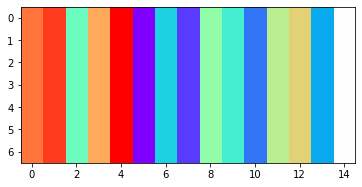

In [113]:
# Create Colors
cols = cm.rainbow(np.linspace(0, 1, len(ids))).tolist()
random.shuffle(cols)
col_map = {ids[i]: np.array(list(map(lambda x: (int)(x * 255), cols[i]))) for i in range(len(ids))}
col_map[-1] = np.ones(4) # Root is white 

# Display test colors
px_row = [[1, col_map[id]] for id in col_map]
test_px = line_from_data(px_row, len(px_row))
array = np.array([test_px] * (len(px_row) // 2), dtype=np.uint8)
new_image = Image.fromarray(array)
print("Legend:")
plt.imshow(new_image)

In [114]:
def get_pop_dict(pops_df, ids, fg, lg, gen, max_pop, normalize):
    pop_dict = { cloneId: count for cloneId in ids if (count := get_count_at_gen(pops_df, fg, lg, gen, cloneId)) > 0 }
    if not normalize:
        pop_count = sum(pop_dict.values())
        remainder = max_pop - pop_count
        pop_dict[-1] = remainder
    return pop_dict

def rec_descend(tree, pop_dict, cloneId):
    res = []
    if cloneId in tree:
        if cloneId in pop_dict:
            pop = pop_dict[cloneId] / 2
            res += [(pop, cloneId)]
            for childId in tree[cloneId]:
                res += rec_descend(tree, pop_dict, childId) 
            res += [(pop, cloneId)]
        else: 
            for childId in tree[cloneId]:
                res += rec_descend(tree, pop_dict, childId) 
    elif cloneId in pop_dict:
        return [(pop_dict[cloneId], cloneId)]
    return res

def get_image_pixels(tree, ids, rootId, pop_df, col_map, max_pop, breath, first_gen, last_gen, normalize = True):    
    img_pixels = []
    for i in progressbar(range(first_gen, last_gen), "Converting generation: "):
        pop_dict = get_pop_dict(pop_df, ids, first_gen, last_gen, i, max_pop, normalize)
        if len(pop_dict) > 0:
            id_rows = rec_descend(tree, pop_dict, rootId if normalize else -1)
            pixel_row = [(id_row[0], col_map[id_row[1]]) for id_row in id_rows]
        else: 
            pixel_row = [(-1, np.ones(4) * 127)]
        line_px = line_from_data(pixel_row, breath)
        img_pixels.append(line_px)
    return img_pixels

def pixels_to_img(img_pixels, res):
    px_array = np.array(img_pixels, dtype=np.uint8)
    new_image = Image.fromarray(px_array).transpose(Image.ROTATE_270).transpose(Image.FLIP_LEFT_RIGHT)
    resized = new_image.resize(res)
    return resized

In [115]:
populations_df["Gen"].min()

0

In [116]:
gen_count = populations_df["Gen"].max() - populations_df["Gen"].min()
populations_df["Gen"] = populations_df["Gen"] * res[0] / gen_count
pop_sizes = populations_df[["Gen", "Pop"]].groupby("Gen", as_index=False).sum()
first_gen = int(math.ceil(populations_df["Gen"].min()))
last_gen = int(populations_df["Gen"].max())
max_pop = pop_sizes["Pop"].max()
img_pixels = get_image_pixels(tree, ids, rootId, populations_df, col_map, max_pop, res[1], first_gen, last_gen, True)

Converting generation: [############################################################] 1080/1080


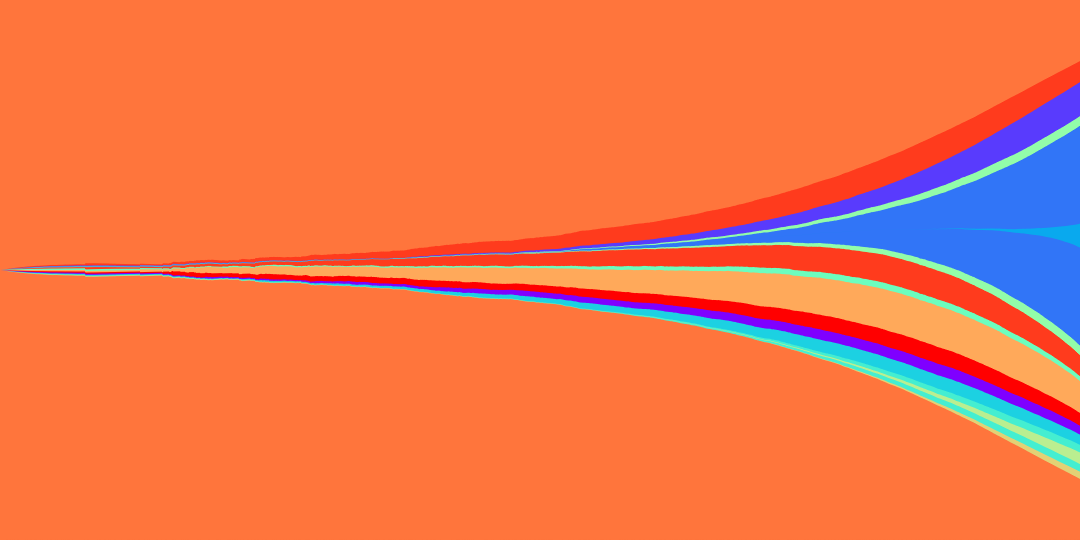

In [117]:
pixels_to_img(img_pixels, res)

    Id    Gen  Pop
0    0    0.0  100
1    0   54.0   40
2    0  108.0   20
3    0  162.0   10
4    1   54.0   10
5    1  162.0   50
6    1  270.0  100
7    2  216.0    0
8    2  270.0   50
9    3    0.0   10
10   3  270.0   20
     Gen  Pop
0    0.0  110
1   54.0   50
2  108.0   20
3  162.0   60
4  216.0    0
5  270.0  170
0 270 170
[0 1]
[1 2 3]
[0]
0
ids [0 1 2 3]
{0: [1, 3], 1: [2], -1: [0]}
Count 100.0
[ 42 220 220 255]
[ 98.66666667 220.         189.         255.        ]
{0: 100.0, 3: 10.0, -1: 60.0}
Converting generation: [############################################################] 270/270


[Text(0, 0.0, '170.0'),
 Text(0, 135.0, '127.5'),
 Text(0, 270.0, '85.0'),
 Text(0, 405.0, '42.5'),
 Text(0, 540.0, '0.0')]

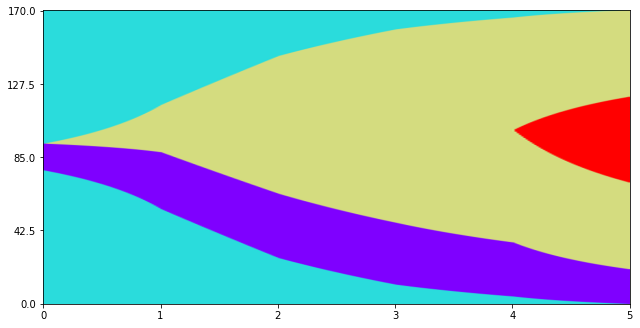

In [104]:
populations_df = pd.read_csv("test_pop.csv")
parent_df = pd.read_csv("test_pt.csv")
populations_df["Gen"] = populations_df["Gen"] * res[0] / int(populations_df["Gen"].max()) / 4
print(populations_df)
pop_sizes = populations_df[["Gen", "Pop"]].groupby("Gen", as_index=False).sum()
print(pop_sizes)
first_gen = int(math.ceil(populations_df["Gen"].min()))
last_gen = int(populations_df["Gen"].max())
max_pop = pop_sizes["Pop"].max()
print(first_gen, last_gen, max_pop)

parents = parent_df["ParentId"].unique()
print(parents)
children = parent_df["ChildId"].unique()
print(children)
root_list = np.setdiff1d(parents, children)
print(root_list)
rootId = root_list[0]
print(rootId)
ids = np.concatenate([[rootId], children])
print("ids", ids)
tree = build_tree(parent_df, ids, rootId)
print(tree)
count = get_count_at_gen(populations_df, first_gen, last_gen, 0, 0)
print("Count", count)

# Create Colors
cols = cm.rainbow(np.linspace(0, 1, len(ids))).tolist()
random.shuffle(cols)
col_map = {ids[i]: np.array(list(map(lambda x: (int)(x * 255), cols[i]))) for i in range(len(ids))}
col_map[-1] = np.ones(4) # Root is white 
print(col_map[0])

# Display test colors
px_row = [[colId + 2, col_map[colId]] for colId in col_map]
test_px = line_from_data(px_row, len(px_row))
print(test_px[0])

pop_dict = get_pop_dict(populations_df, ids, first_gen, last_gen, 0, max_pop, False)
print(pop_dict)

img_pixels = get_image_pixels(tree, ids, rootId, populations_df, col_map, max_pop, res[1] * scale_up, first_gen, last_gen, True)
img = pixels_to_img(img_pixels, res)
fig, ax = plt.subplots(1,1, figsize=np.array(res)/100)
im_plot = ax.imshow(img)
ax.set_xticks(np.array([0,1,2,3,4,5]) / 5.0 * res[0])
ax.set_xticklabels([0,1,2,3,4,5])
ax.set_yticks(np.array([0,1,2,3,4]) / 4.0 * res[1])
ax.set_yticklabels((np.array([4, 3,2,1,0]) / 4.0 * max_pop).round(2))

In [99]:
(np.array([3,2,1,0]) / 3.0 * res[1]).round(2)

array([540., 360., 180.,   0.])